# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  🧠 Deep Learning Training Pipeline — CIC-IDS-2018                        ║
# ║  Phase 2: Optimization — Feature Importance (Random Forest) Selection      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Adaptation from PCA → Feature Importance
# ─────────────────────────────────────────
# PCA :         StandardScaler → PCA (57 → 30 components)  [unsupervised, creates new axes]
# Feature Imp.: StandardScaler → RandomForest importance → select Top-K features  [supervised, keeps original features]
#
# Key principle preserved (same as PCA notebook):
#   • Fit on TRAIN only → no data leakage
#   • Same models (1D-CNN, LSTM), same callbacks, same metrics
#   • Scaler + selector saved (pkl) per model for inference
#   • N_FEATURES_TO_SELECT = 30  (same dimensionality target as N_COMPONENTS=30)


# ─────────────────────────────────────────────────────────────────────────────
# 1. Import Libraries
# ─────────────────────────────────────────────────────────────────────────────


In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
import os
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, Dense, Flatten, LSTM, Reshape
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, balanced_accuracy_score
)
 
import matplotlib.pyplot as plt
import seaborn as sns
 
# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)
 
# ── GPU Configuration ─────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f'✅ GPU enabled: {len(gpus)} Physical GPU(s), '
              f'{len(logical_gpus)} Logical GPU(s)')
        for g in gpus:
            print(f'   {g.name}')
    except RuntimeError as e:
        print(f'⚠️  GPU config error: {e}')
else:
    print('⚠️  No GPU detected — running on CPU.')
 
print()
print('=' * 80)
print('🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | FEATURE IMPORTANCE OPTIMIZATION')
print('=' * 80)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU devices: {gpus}')


⚠️  No GPU detected — running on CPU.

🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | FEATURE IMPORTANCE OPTIMIZATION
TensorFlow : 2.21.0
Keras      : 3.13.2
GPU devices: []


# ─────────────────────────────────────────────────────────────────────────────
# 2. Configuration
# ─────────────────────────────────────────────────────────────────────────────


In [2]:
INPUT_FILE     = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR = 'trained_models/dl_optimized/feature_importance/'
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
SAVE_MODELS    = True
 
# ── Feature Importance configuration ─────────────────────────────────────────
# Equivalent to N_COMPONENTS=30 in PCA: keep the 30 most important features.
# RandomForest is trained on a subsample (FI_SAMPLE_SIZE rows) for speed.
N_FEATURES_TO_SELECT = 30       # Top-K features to keep  (replaces N_COMPONENTS)
FI_SAMPLE_SIZE       = 200_000  # Rows used to fit RF for importance ranking
RF_N_ESTIMATORS      = 100      # Trees in the Random Forest
RF_MAX_DEPTH         = 10       # Shallow trees → fast + enough for ranking
 
# ── Training hyperparameters (identical to PCA notebook) ─────────────────────
BATCH_SIZE       = 256
EPOCHS           = 20
VALIDATION_SPLIT = 0.1
PATIENCE         = 10
 
# ── Per-model sample sizes ────────────────────────────────────────────────────
MODEL_SAMPLE_SIZES = {
    'CNN' : 10_000_000,   # Full dataset (capped at actual size if smaller)
    'LSTM': 200_000,      # LSTM is slow — 200 k rows
}
 
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
 
print('✅ Configuration set')
print(f'   Top-K features       : {N_FEATURES_TO_SELECT}  (replaces PCA n_components=30)')
print(f'   RF sample size       : {FI_SAMPLE_SIZE:,}')
print(f'   RF estimators        : {RF_N_ESTIMATORS}')
print(f'   Batch size           : {BATCH_SIZE}')
print(f'   Max epochs           : {EPOCHS}')
print(f'   Validation split     : {VALIDATION_SPLIT}')
print(f'   EarlyStopping pat.   : {PATIENCE}')
print(f'   Output directory     : {BASE_MODEL_DIR}')
print(f'\n📊 Per-model sample sizes:')
for model, size in MODEL_SAMPLE_SIZES.items():
    s = 'Full dataset' if size is None else f'{size:,} rows'
    print(f'   {model:<6}: {s}')


✅ Configuration set
   Top-K features       : 30  (replaces PCA n_components=30)
   RF sample size       : 200,000
   RF estimators        : 100
   Batch size           : 256
   Max epochs           : 20
   Validation split     : 0.1
   EarlyStopping pat.   : 10
   Output directory     : trained_models/dl_optimized/feature_importance/

📊 Per-model sample sizes:
   CNN   : 10,000,000 rows
   LSTM  : 200,000 rows


# ─────────────────────────────────────────────────────────────────────────────
# 3. Load Dataset
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
CHUNK_SIZE = 100_000
chunks, total = [], 0
 
print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')
 
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 20 == 0:
        print(f'   Chunk {i+1:>4}: {len(chunk):,} rows | Total: {total:,}')
 
df_full = pd.concat(chunks, ignore_index=True)
del chunks
 
df_full = df_full.drop(columns=['Label'], errors='ignore')
 
print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(f'\nRaw class distribution:')
print(df_full['Label_Binary'].value_counts())



📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk   20: 100,000 rows | Total: 2,000,000
   Chunk   40: 100,000 rows | Total: 4,000,000
   Chunk   60: 100,000 rows | Total: 6,000,000
   Chunk   80: 100,000 rows | Total: 8,000,000
   Chunk  100: 100,000 rows | Total: 10,000,000
   Chunk  120: 100,000 rows | Total: 12,000,000
   Chunk  140: 100,000 rows | Total: 14,000,000
   Chunk  160: 100,000 rows | Total: 16,000,000

✅ Dataset loaded
   Rows   : 16,232,943
   Columns: 58

Raw class distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


# ─────────────────────────────────────────────────────────────────────────────
# 4. Prepare Features and Target
# ─────────────────────────────────────────────────────────────────────────────


In [4]:
label_columns   = ['Label', 'Label_Binary']
existing_labels = [c for c in label_columns if c in df_full.columns]
 
X_full = df_full.drop(columns=existing_labels).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary']
feature_names = X_full.columns.tolist()
del df_full
 
print(f'✅ Features (X): {X_full.shape}')
print(f'✅ Target   (y): {y_full.shape}')
print(f'\n📊 Original features     : {X_full.shape[1]}')
print(f'📊 After Feature Select  : {N_FEATURES_TO_SELECT} features '
      f'(reduction: {X_full.shape[1] - N_FEATURES_TO_SELECT} features removed)')
 
print(f'\n📊 Class Distribution:')
vc = y_full.value_counts()
for k, v in vc.items():
    label = 'Benign' if k == 0 else 'Attack'
    print(f'   {label} ({k}): {v:>10,}  ({v/len(y_full)*100:.2f}%)')


✅ Features (X): (16232943, 57)
✅ Target   (y): (16232943,)

📊 Original features     : 57
📊 After Feature Select  : 30 features (reduction: 27 features removed)

📊 Class Distribution:
   Benign (0): 13,484,708  (83.07%)
   Attack (1):  2,748,235  (16.93%)


# ─────────────────────────────────────────────────────────────────────────────
# 5. Compute Global Feature Importance (once — on a subsample)
# ─────────────────────────────────────────────────────────────────────────────


In [5]:
# This mirrors the PCA step but supervised:
#   PCA : fit(X_train_scaled)    → unsupervised directions of max variance
#   Here: fit(X_sub, y_sub)      → supervised importance via RF impurity decrease
#
# We compute importance ONCE on a representative subsample, then the SAME
# top-K feature mask is applied to all models (CNN, LSTM) — consistent ranking.
 
print('\n' + '=' * 80)
print('🌲 COMPUTING FEATURE IMPORTANCE (Random Forest — global ranking)')
print('=' * 80)
print(f'   Sampling {FI_SAMPLE_SIZE:,} rows (stratified) to fit RF...')
 
X_fi_sub, _, y_fi_sub, _ = train_test_split(
    X_full, y_full,
    train_size=FI_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_full
)
 
# Scale before RF (good practice; doesn't affect tree importance but keeps pipeline consistent)
scaler_fi = StandardScaler()
X_fi_scaled = scaler_fi.fit_transform(X_fi_sub)
 
print(f'   Training Random Forest ({RF_N_ESTIMATORS} trees, max_depth={RF_MAX_DEPTH})...')
t0_fi = time.time()
rf_selector = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'   # handle class imbalance during importance computation
)
rf_selector.fit(X_fi_scaled, y_fi_sub)
fi_time = time.time() - t0_fi
print(f'   ✅ RF fitted in {fi_time:.2f}s')
 
importances     = rf_selector.feature_importances_
fi_series       = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top_features    = fi_series.head(N_FEATURES_TO_SELECT).index.tolist()
top_indices     = [feature_names.index(f) for f in top_features]
 
print(f'\n📊 Feature Importance Summary:')
print(f'   Total features           : {len(feature_names)}')
print(f'   Features selected (Top-K): {len(top_features)}')
print(f'   Variance covered by top-K: {fi_series.head(N_FEATURES_TO_SELECT).sum()*100:.2f}%  '
      f'(importance sum, analogous to PCA variance)')
print(f'\n   Top 10 features by importance:')
for rank, (feat, imp) in enumerate(fi_series.head(10).items(), 1):
    print(f'      {rank:>2}. {feat:<40} {imp:.6f}')
 
# Save global selector info
if SAVE_MODELS:
    os.makedirs(BASE_MODEL_DIR, exist_ok=True)
    with open(os.path.join(BASE_MODEL_DIR, 'rf_selector.pkl'), 'wb') as f:
        pickle.dump(rf_selector, f)
    with open(os.path.join(BASE_MODEL_DIR, 'top_features.pkl'), 'wb') as f:
        pickle.dump({'top_features': top_features, 'top_indices': top_indices}, f)
    fi_series.to_csv(os.path.join(BASE_MODEL_DIR, 'feature_importances.csv'))
    print(f'\n   💾 RF selector & feature list saved to {BASE_MODEL_DIR}')



🌲 COMPUTING FEATURE IMPORTANCE (Random Forest — global ranking)
   Sampling 200,000 rows (stratified) to fit RF...
   Training Random Forest (100 trees, max_depth=10)...
   ✅ RF fitted in 2.82s

📊 Feature Importance Summary:
   Total features           : 57
   Features selected (Top-K): 30
   Variance covered by top-K: 86.49%  (importance sum, analogous to PCA variance)

   Top 10 features by importance:
       1. Dst Port                                 0.088297
       2. Init Fwd Win Byts                        0.074239
       3. Fwd Pkt Len Max                          0.067336
       4. Fwd Pkt Len Mean                         0.054232
       5. Init Bwd Win Byts                        0.051539
       6. Subflow Fwd Byts                         0.047067
       7. TotLen Fwd Pkts                          0.043020
       8. Fwd Header Len                           0.038763
       9. Flow Pkts/s                              0.036427
      10. Fwd Pkts/s                               

# ─────────────────────────────────────────────────────────────────────────────
# 6. Helper Functions
# ─────────────────────────────────────────────────────────────────────────────


In [6]:
def get_model_data(X_full, y_full, model_name, sample_size,
                   test_size, random_state):
    """Stratified sample (optional) → train/test split. Returns raw numpy arrays."""
    if sample_size is None or sample_size >= len(X_full):
        if sample_size is not None:
            print(f'   ⚠️  Requested {sample_size:,} rows but only '
                  f'{len(X_full):,} available — using full dataset')
        X, y = X_full, y_full
        print(f'   📊 Using full dataset: {len(X):,} rows')
    else:
        print(f'   📊 Sampling {sample_size:,} rows from {len(X_full):,} (stratified)')
        X, _, y, _ = train_test_split(
            X_full, y_full,
            train_size=sample_size,
            random_state=random_state,
            stratify=y_full
        )
 
    print(f'\n   📊 Class distribution in sample:')
    for k, v in y.value_counts().items():
        label = 'Benign' if k == 0 else 'Attack'
        print(f'      {label} ({k}): {v:>10,}  ({v/len(y)*100:.2f}%)')
 
    print(f'\n   ✂️  Splitting train/test ({test_size*100:.0f}% test)...')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f'   ✅ Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
    return X_train, X_test, y_train, y_test
 
 
def apply_feature_importance_pipeline(X_train, X_test, top_indices):
    """
    StandardScaler → Select Top-K features by pre-computed importance indices.
 
    ─── Analogy with PCA pipeline ────────────────────────────────────────────
    PCA pipeline  : scaler.fit_transform(X_train) → pca.fit_transform(X_train_scaled)
    FI  pipeline  : scaler.fit_transform(X_train) → X_train_scaled[:, top_indices]
    ──────────────────────────────────────────────────────────────────────────
    Fit on train only — no data leakage.
    The top_indices are fixed (computed globally before this function).
    Returns transformed arrays + fitted scaler (selector is just index slicing).
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
 
    # Feature selection = column indexing (deterministic, no fitting needed)
    X_train_fi = X_train_scaled[:, top_indices]
    X_test_fi  = X_test_scaled[:, top_indices]
 
    print(f'   Original dims    : {X_train.shape[1]}')
    print(f'   Selected dims    : {X_train_fi.shape[1]}  (Top-{len(top_indices)} features)')
    print(f'   Features removed : {X_train.shape[1] - X_train_fi.shape[1]}')
    importance_coverage = fi_series.iloc[:len(top_indices)].sum() * 100
    print(f'   Importance sum   : {importance_coverage:.2f}%  '
          f'(analogous to PCA variance explained)')
    return X_train_fi, X_test_fi, scaler
 
 
print('\n✅ Helper functions defined')



✅ Helper functions defined


# ─────────────────────────────────────────────────────────────────────────────
# 7. Model Architectures  (identical to PCA notebook — only input_dim changes)
# ─────────────────────────────────────────────────────────────────────────────
# Input is now N_FEATURES_TO_SELECT (=30) real original features, not PCA axes.
# Architecture is unchanged → fair comparison between optimization strategies.


In [7]:
def build_cnn_model(n_features):
    """1D CNN — input: top-K selected features (same arch as PCA notebook)."""
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        Conv1D(64,  kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model
 
 
def build_lstm_model(n_features):
    """LSTM — input: top-K selected features (same arch as PCA notebook)."""
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model
 
 
MODEL_BUILDERS = {
    'CNN' : build_cnn_model,
    'LSTM': build_lstm_model,
}
 
print(f'✅ Defined {len(MODEL_BUILDERS)} model builders: {list(MODEL_BUILDERS.keys())}')


✅ Defined 2 model builders: ['CNN', 'LSTM']


# ─────────────────────────────────────────────────────────────────────────────
# 8. Train All Models
# ─────────────────────────────────────────────────────────────────────────────


In [8]:
results   = {}
histories = {}
 
for model_name, model_builder in MODEL_BUILDERS.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name} WITH FEATURE IMPORTANCE SELECTION')
    print('=' * 80)
 
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower())
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')
 
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
 
    # ── Prepare raw data ──────────────────────────────────────────────────
    print(f'\n📂 Preparing data for {model_name}...')
    X_train_raw, X_test_raw, y_train, y_test = get_model_data(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
 
    # ── StandardScaler + Top-K Feature Selection (fit on train only) ──────
    # Replaces: apply_pca_pipeline(X_train_raw, X_test_raw, N_COMPONENTS, RANDOM_STATE)
    print(f'\n🔬 Applying scaling + feature importance selection (fit on train only — no leakage)...')
    X_train_fi, X_test_fi, scaler = apply_feature_importance_pipeline(
        X_train_raw, X_test_raw, top_indices
    )
 
    # ── Save transformers (scaler + top_indices — replaces scaler + pca.pkl) ─
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
            pickle.dump(scaler, f)
        with open(os.path.join(model_dir, 'top_indices.pkl'), 'wb') as f:
            pickle.dump(top_indices, f)
        print(f'   💾 Scaler & top_indices saved')
 
    # ── Build model (input dim = N_FEATURES_TO_SELECT = 30) ───────────────
    print(f'\n🔨 Building {model_name} model (input: {N_FEATURES_TO_SELECT} selected features)...')
    model = model_builder(N_FEATURES_TO_SELECT)
    model.summary()
 
    # ── Callbacks (identical to PCA notebook) ─────────────────────────────
    best_model_path = os.path.join(model_dir, 'best_model.keras')
    cb_list = [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=max(2, PATIENCE // 3),
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss', save_best_only=True, verbose=1
        )
    ]
 
    # ── Train ─────────────────────────────────────────────────────────────
    print(f'\n⏱️  Training {model_name} with feature-importance-selected features...')
    start_time = time.time()
 
    history = model.fit(
        X_train_fi, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=cb_list,
        verbose=1
    )
 
    train_time = time.time() - start_time
    print(f'\n✅ Training completed in {train_time:.2f}s ({train_time/60:.2f} min)')
 
    # ── Evaluate ──────────────────────────────────────────────────────────
    print(f'\n🔮 Evaluating on test set...')
    start_eval  = time.time()
    y_pred_prob = model.predict(X_test_fi, batch_size=BATCH_SIZE, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
    pred_time   = time.time() - start_eval
    print(f'✅ Predictions completed in {pred_time:.2f}s')
 
    # ── Compute metrics (identical to PCA notebook) ───────────────────────
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
 
    accuracy         = accuracy_score(y_test, y_pred)
    f1_macro         = f1_score(y_test, y_pred, average='macro',  zero_division=0)
    bal_acc          = balanced_accuracy_score(y_test, y_pred)
    benign_recall    = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    attack_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    benign_precision = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    attack_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
 
    importance_coverage = float(fi_series.iloc[:N_FEATURES_TO_SELECT].sum())
 
    print(f'\n📊 RESULTS WITH FEATURE IMPORTANCE:')
    print(f'   Balanced Accuracy    : {bal_acc:.4f}  ← primary metric')
    print(f'   F1 Macro             : {f1_macro:.4f}')
    print(f'   Benign Recall        : {benign_recall:.4f}')
    print(f'   Attack Recall        : {attack_recall:.4f}')
    print(f'   Benign Precision     : {benign_precision:.4f}')
    print(f'   Attack Precision     : {attack_precision:.4f}')
    print(f'   Plain Accuracy       : {accuracy:.4f}  ⚠️  (misleading on imbalanced data)')
    print(f'   Importance Coverage  : {importance_coverage*100:.2f}%  (analogous to PCA variance explained)')
 
    print(f'\n🕐 TIME:')
    print(f'   Train: {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Eval : {pred_time:.2f}s')
 
    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    print(f'   TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}')
 
    print(f'\n📋 Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Benign', 'Attack'], zero_division=0))
 
    # ── Store results ─────────────────────────────────────────────────────
    results[model_name] = {
        'balanced_accuracy'   : float(bal_acc),
        'f1_macro'            : float(f1_macro),
        'benign_recall'       : float(benign_recall),
        'attack_recall'       : float(attack_recall),
        'benign_precision'    : float(benign_precision),
        'attack_precision'    : float(attack_precision),
        'accuracy'            : float(accuracy),
        'train_time'          : train_time,
        'pred_time'           : pred_time,
        'confusion_matrix'    : cm,
        'sample_size'         : len(X_train_raw) + len(X_test_raw),
        'train_samples'       : len(X_train_raw),
        'test_samples'        : len(X_test_raw),
        'epochs_trained'      : len(history.history['loss']),
        'importance_coverage' : importance_coverage,
        'TN': int(TN), 'FP': int(FP), 'FN': int(FN), 'TP': int(TP)
    }
    histories[model_name] = history
 
    # ── Save model + metadata ─────────────────────────────────────────────
    if SAVE_MODELS:
        final_path = os.path.join(model_dir, 'final_model.keras')
        model.save(final_path)
        print(f'\n💾 Final model saved : {final_path}')
        print(f'💾 Best model saved  : {best_model_path}')
 
        with open(os.path.join(model_dir, 'history.pkl'), 'wb') as f:
            pickle.dump(history.history, f)
 
        metadata = {
            'model_name'         : model_name,
            'optimization'       : 'FeatureImportance',
            'n_features_selected': N_FEATURES_TO_SELECT,
            'top_features'       : top_features,
            'sample_size'        : sample_size,
            'train_samples'      : len(X_train_raw),
            'test_samples'       : len(X_test_raw),
            'epochs'             : EPOCHS,
            'epochs_trained'     : len(history.history['loss']),
            'batch_size'         : BATCH_SIZE,
            'train_time'         : train_time,
            'metrics': {
                'balanced_accuracy'   : float(bal_acc),
                'f1_macro'            : float(f1_macro),
                'benign_recall'       : float(benign_recall),
                'attack_recall'       : float(attack_recall),
                'accuracy'            : float(accuracy),
                'importance_coverage' : importance_coverage,
            }
        }
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Metadata saved    : {os.path.join(model_dir, "metadata.pkl")}')
 
print('\n' + '=' * 80)
print('✅ ALL DEEP LEARNING MODELS TRAINED & TESTED WITH FEATURE IMPORTANCE!')
print('=' * 80)



🚀 TRAINING: CNN WITH FEATURE IMPORTANCE SELECTION
📁 Model directory: trained_models/dl_optimized/feature_importance/cnn

📂 Preparing data for CNN...
   📊 Sampling 10,000,000 rows from 16,232,943 (stratified)

   📊 Class distribution in sample:
      Benign (0):  8,307,001  (83.07%)
      Attack (1):  1,692,999  (16.93%)

   ✂️  Splitting train/test (20% test)...
   ✅ Train: 8,000,000 | Test: 2,000,000

🔬 Applying scaling + feature importance selection (fit on train only — no leakage)...
   Original dims    : 57
   Selected dims    : 30  (Top-30 features)
   Features removed : 27
   Importance sum   : 86.49%  (analogous to PCA variance explained)
   💾 Scaler & top_indices saved

🔨 Building CNN model (input: 30 selected features)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,377 (583.50 KB)

 Trainable params: 148,737 (581.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,009 (480.50 KB)

 Trainable params: 122,625 (479.00 KB)

 Non-trainable params: 384 (1.50 KB)


⏱️  Training LSTM with feature-importance-selected features...
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8631 - loss: 0.3228 - precision: 0.6502 - recall: 0.4241
Epoch 1: val_loss improved from None to 0.21074, saving model to trained_models/dl_optimized/feature_importance/lstm\best_model.keras

Epoch 1: finished saving model to trained_models/dl_optimized/feature_importance/lstm\best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 59s 101ms/step - accuracy: 0.9129 - loss: 0.2298 - precision: 0.8298 - recall: 0.6113 - val_accuracy: 0.8976 - val_loss: 0.2107 - val_precision: 0.9234 - val_recall: 0.4258 - learning_rate: 0.0010
Epoch 2/20
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9528 - loss: 0.1415 - precision: 0.9379 - recall: 0.7742
Epoch 2: val_loss improved from 0.21074 to 0.08464, saving model to trained_models/dl_optimized/feature_importance/lstm\best_model.keras

Epoch 2: finished saving model to trained_models/dl_optimized/feature_importance/lstm\

# ─────────────────────────────────────────────────────────────────────────────
# 9. Results Summary
# ─────────────────────────────────────────────────────────────────────────────


In [9]:
summary_df = pd.DataFrame(results).T
metric_cols = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'accuracy', 'importance_coverage', 'train_time', 'epochs_trained', 'sample_size'
]
summary_df = summary_df[metric_cols].astype({c: float for c in metric_cols})
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)
 
print('\n' + '=' * 80)
print('📊 FINAL RESULTS — FEATURE IMPORTANCE OPTIMIZATION')
print('=' * 80)
print('\nRanked by Balanced Accuracy:')
print(summary_df[[
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'accuracy'
]].to_string())
 
print('\n⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2')
print('    importance_coverage = sum of RF importances of selected features')
print('    (analogous to PCA explained variance)')
 
summary_df.to_csv(os.path.join(BASE_MODEL_DIR, 'results_summary.csv'))
print(f'\n✅ Results saved → {BASE_MODEL_DIR}results_summary.csv')



📊 FINAL RESULTS — FEATURE IMPORTANCE OPTIMIZATION

Ranked by Balanced Accuracy:
      balanced_accuracy  f1_macro  benign_recall  attack_recall  benign_precision  attack_precision  accuracy
CNN            0.969335  0.980841       0.999796       0.938875          0.987693          0.998935  0.989482
LSTM           0.966102  0.976118       0.997472       0.934731          0.986840          0.986904  0.986850

⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2
    importance_coverage = sum of RF importances of selected features
    (analogous to PCA explained variance)

✅ Results saved → trained_models/dl_optimized/feature_importance/results_summary.csv


# ─────────────────────────────────────────────────────────────────────────────
# 10. Training History — Loss & Accuracy Curves
# ─────────────────────────────────────────────────────────────────────────────



📊 Plotting training history...
✅ Saved → trained_models/dl_optimized/feature_importance/training_history.png


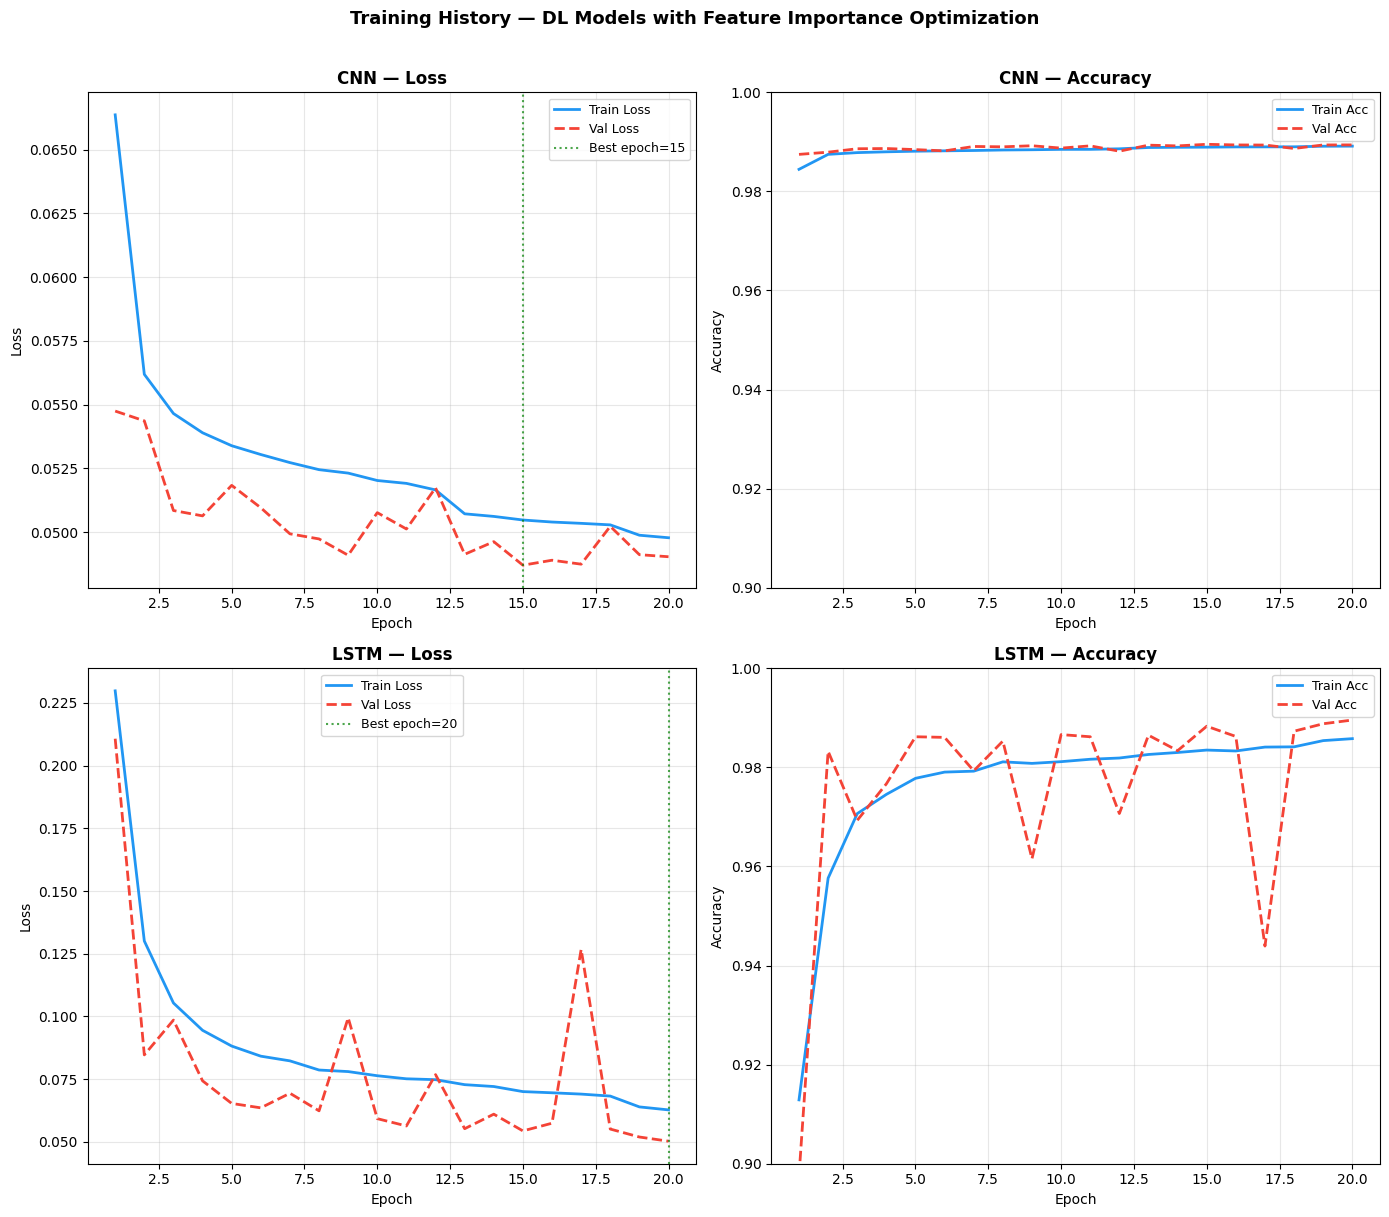

In [10]:
print('\n📊 Plotting training history...')
 
n_models = len(histories)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 6 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)
 
for idx, (model_name, history) in enumerate(histories.items()):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)
 
    axes[idx, 0].plot(epochs_range, h['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
    axes[idx, 0].plot(epochs_range, h['val_loss'], label='Val Loss',   color='#F44336', linewidth=2, linestyle='--')
    best_ep = np.argmin(h['val_loss']) + 1
    axes[idx, 0].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best epoch={best_ep}')
    axes[idx, 0].set_title(f'{model_name} — Loss', fontweight='bold', fontsize=12)
    axes[idx, 0].set_xlabel('Epoch'); axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend(fontsize=9);  axes[idx, 0].grid(alpha=0.3)
 
    axes[idx, 1].plot(epochs_range, h['accuracy'],     label='Train Acc', color='#2196F3', linewidth=2)
    axes[idx, 1].plot(epochs_range, h['val_accuracy'], label='Val Acc',   color='#F44336', linewidth=2, linestyle='--')
    axes[idx, 1].set_title(f'{model_name} — Accuracy', fontweight='bold', fontsize=12)
    axes[idx, 1].set_xlabel('Epoch'); axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend(fontsize=9);  axes[idx, 1].grid(alpha=0.3)
    axes[idx, 1].set_ylim(0.9, 1.0)
 
plt.suptitle('Training History — DL Models with Feature Importance Optimization',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
hist_path = os.path.join(BASE_MODEL_DIR, 'training_history.png')
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {hist_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. Performance Comparison Charts
# ─────────────────────────────────────────────────────────────────────────────



📊 Creating performance comparison plots...
✅ Saved → trained_models/dl_optimized/feature_importance/metrics_comparison.png


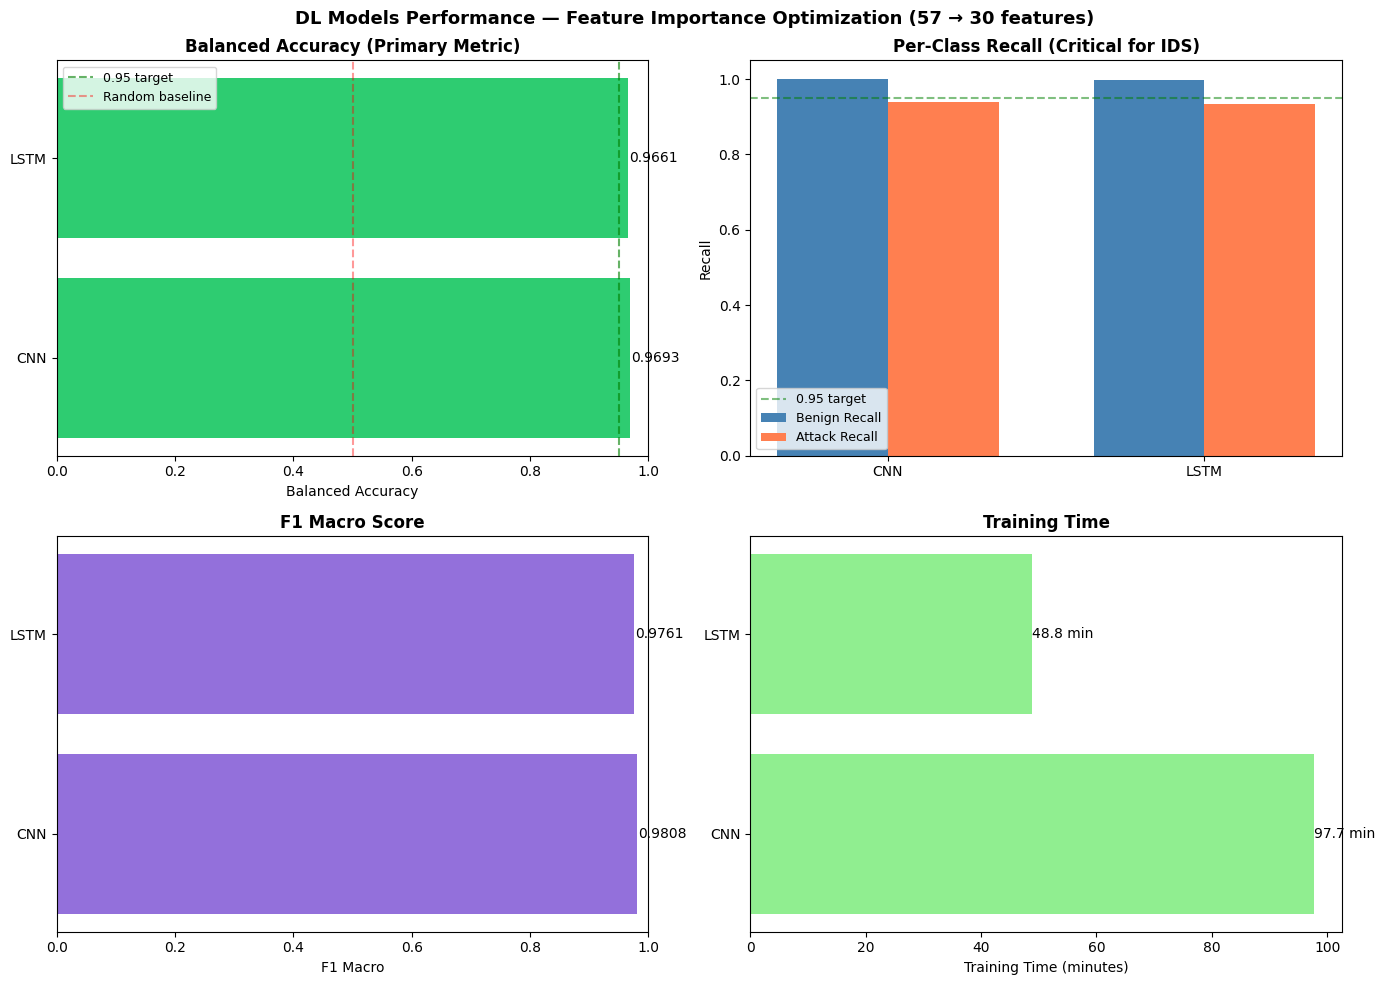

In [11]:
print('\n📊 Creating performance comparison plots...')
 
model_names = summary_df.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'DL Models Performance — Feature Importance Optimization (57 → {N_FEATURES_TO_SELECT} features)',
    fontsize=13, fontweight='bold'
)
 
colors_ba = ['#2ecc71' if v >= 0.95 else '#f39c12' if v >= 0.90 else '#e74c3c'
             for v in summary_df['balanced_accuracy']]
axes[0, 0].barh(model_names, summary_df['balanced_accuracy'], color=colors_ba)
axes[0, 0].set_xlabel('Balanced Accuracy')
axes[0, 0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].axvline(0.95, color='green', linestyle='--', alpha=0.6, label='0.95 target')
axes[0, 0].axvline(0.5,  color='red',   linestyle='--', alpha=0.4, label='Random baseline')
for i, v in enumerate(summary_df['balanced_accuracy']):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
axes[0, 0].legend(fontsize=9)
 
x = np.arange(len(model_names)); width = 0.35
axes[0, 1].bar(x - width/2, summary_df['benign_recall'], width, label='Benign Recall', color='steelblue')
axes[0, 1].bar(x + width/2, summary_df['attack_recall'], width, label='Attack Recall', color='coral')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Per-Class Recall (Critical for IDS)', fontweight='bold')
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(model_names, fontsize=10)
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].axhline(0.95, color='green', linestyle='--', alpha=0.5, label='0.95 target')
axes[0, 1].legend(fontsize=9)
 
axes[1, 0].barh(model_names, summary_df['f1_macro'], color='mediumpurple')
axes[1, 0].set_xlabel('F1 Macro')
axes[1, 0].set_title('F1 Macro Score', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['f1_macro']):
    axes[1, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
 
axes[1, 1].barh(model_names, summary_df['train_time'] / 60, color='lightgreen')
axes[1, 1].set_xlabel('Training Time (minutes)')
axes[1, 1].set_title('Training Time', fontweight='bold')
for i, v in enumerate(summary_df['train_time'] / 60):
    axes[1, 1].text(v + 0.05, i, f'{v:.1f} min', va='center', fontsize=10)
 
plt.tight_layout()
comp_path = os.path.join(BASE_MODEL_DIR, 'metrics_comparison.png')
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {comp_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 12. Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/feature_importance/confusion_matrices.png


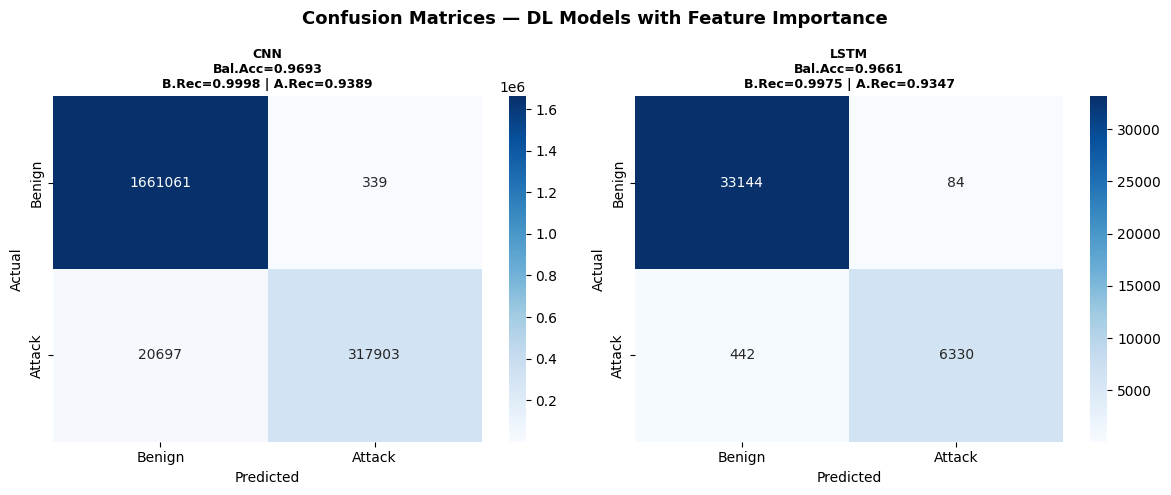

In [12]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]
 
for idx, model_name in enumerate(summary_df.index):
    r  = results[model_name]
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[idx].set_title(
        f'{model_name}\nBal.Acc={r["balanced_accuracy"]:.4f}\n'
        f'B.Rec={r["benign_recall"]:.4f} | A.Rec={r["attack_recall"]:.4f}',
        fontweight='bold', fontsize=9
    )
    axes[idx].set_ylabel('Actual'); axes[idx].set_xlabel('Predicted')
 
plt.suptitle('Confusion Matrices — DL Models with Feature Importance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(BASE_MODEL_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {cm_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 13. Feature Importance Analysis  (replaces PCA Scree Plot)
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/feature_importance/feature_importance_analysis.png


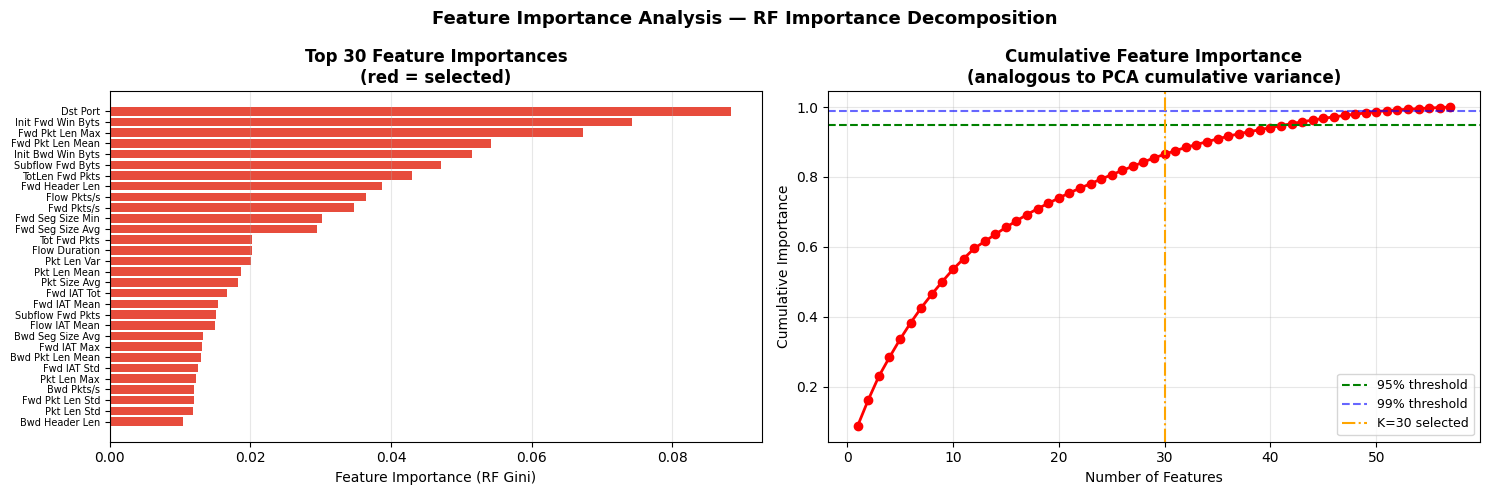


📊 Feature Importance Analysis:
   Features selected       : 30
   Importance coverage     : 86.49%
   Top  5 features cover   : 33.56%
   Top 10 features cover   : 53.57%
   Top 20 features cover   : 73.97%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
# Bar chart — top-K importances  (≈ Scree plot for PCA)
top_n_plot = min(30, len(fi_series))
fi_top = fi_series.head(top_n_plot)
colors_bar = ['#e74c3c' if f in top_features else '#3498db' for f in fi_top.index]
axes[0].barh(range(top_n_plot), fi_top.values[::-1], color=colors_bar[::-1])
axes[0].set_yticks(range(top_n_plot))
axes[0].set_yticklabels(fi_top.index[::-1], fontsize=7)
axes[0].set_xlabel('Feature Importance (RF Gini)')
axes[0].set_title(f'Top {top_n_plot} Feature Importances\n(red = selected)', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
 
# Cumulative importance  (≈ Cumulative variance for PCA)
cumsum_imp = np.cumsum(fi_series.values)
axes[1].plot(range(1, len(cumsum_imp) + 1), cumsum_imp, 'ro-', linewidth=2)
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.99, color='b', linestyle='--', alpha=0.6, label='99% threshold')
axes[1].axvline(x=N_FEATURES_TO_SELECT, color='orange', linestyle='-.',
                label=f'K={N_FEATURES_TO_SELECT} selected')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance\n(analogous to PCA cumulative variance)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('Feature Importance Analysis — RF Importance Decomposition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fi_path = os.path.join(BASE_MODEL_DIR, 'feature_importance_analysis.png')
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {fi_path}')
plt.show()
 
print(f'\n📊 Feature Importance Analysis:')
print(f'   Features selected       : {N_FEATURES_TO_SELECT}')
print(f'   Importance coverage     : {cumsum_imp[N_FEATURES_TO_SELECT-1]*100:.2f}%')
print(f'   Top  5 features cover   : {cumsum_imp[4]*100:.2f}%')
print(f'   Top 10 features cover   : {cumsum_imp[9]*100:.2f}%')
print(f'   Top 20 features cover   : {cumsum_imp[19]*100:.2f}%')


# ─────────────────────────────────────────────────────────────────────────────
# 14. Final Summary
# ─────────────────────────────────────────────────────────────────────────────


In [14]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — FEATURE IMPORTANCE OPTIMIZATION')
print('=' * 80)
 
print(f'\n📊 Models Ranked by Balanced Accuracy:')
print(f'   {"Rank":<4} {"Model":<6} {"Bal.Acc":>8} '
      f'{"B.Recall":>9} {"A.Recall":>9} {"F1-Mac":>7} '
      f'{"ImpCov":>7} {"Epochs":>7} {"Time":>8}')
print('   ' + '─' * 72)
for rank, (model_name, row) in enumerate(summary_df.iterrows(), 1):
    t_str = f'{row["train_time"]/60:.1f}min'
    print(f'   {rank:<4} {model_name:<6} '
          f'{row["balanced_accuracy"]:>8.4f} '
          f'{row["benign_recall"]:>9.4f} '
          f'{row["attack_recall"]:>9.4f} '
          f'{row["f1_macro"]:>7.4f} '
          f'{row["importance_coverage"]*100:>6.2f}% '
          f'{int(row["epochs_trained"]):>7} '
          f'{t_str:>8}')
 
best = summary_df.index[0]
print(f'\n🏆 Best model: {best}')
print(f'   Balanced Accuracy   : {summary_df.loc[best, "balanced_accuracy"]:.4f}')
print(f'   Benign Recall       : {summary_df.loc[best, "benign_recall"]:.4f}')
print(f'   Attack Recall       : {summary_df.loc[best, "attack_recall"]:.4f}')
print(f'   Importance Coverage : {summary_df.loc[best, "importance_coverage"]*100:.2f}%')
 
print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')
for model_name in MODEL_BUILDERS:
    d = os.path.join(BASE_MODEL_DIR, model_name.lower())
    print(f'   {d}/')
    print(f'     best_model.keras   ← best val_loss checkpoint')
    print(f'     final_model.keras  ← end-of-training weights')
    print(f'     scaler.pkl         ← StandardScaler (fit on train)')
    print(f'     top_indices.pkl    ← selected feature indices  [replaces pca.pkl]')
    print(f'     history.pkl')
    print(f'     metadata.pkl')
 
print(f'\n📁 Global files saved to: {BASE_MODEL_DIR}')
print(f'   rf_selector.pkl            ← Random Forest used for ranking')
print(f'   top_features.pkl           ← feature names + indices')
print(f'   feature_importances.csv    ← full importance ranking')
 
print('\n💡 PCA vs Feature Importance — key difference:')
print('   PCA : creates NEW axes (linear combinations) — not interpretable')
print('   FI  : keeps ORIGINAL features — fully interpretable')
print(f'\n   Feature Importance: 57 original features → Top {N_FEATURES_TO_SELECT} kept.')
print('   Analogous metric: importance coverage ≈ PCA explained variance.')



🎉 TRAINING COMPLETE — FEATURE IMPORTANCE OPTIMIZATION

📊 Models Ranked by Balanced Accuracy:
   Rank Model   Bal.Acc  B.Recall  A.Recall  F1-Mac  ImpCov  Epochs     Time
   ────────────────────────────────────────────────────────────────────────
   1    CNN      0.9693    0.9998    0.9389  0.9808  86.49%      20  97.7min
   2    LSTM     0.9661    0.9975    0.9347  0.9761  86.49%      20  48.8min

🏆 Best model: CNN
   Balanced Accuracy   : 0.9693
   Benign Recall       : 0.9998
   Attack Recall       : 0.9389
   Importance Coverage : 86.49%

📁 All models saved to: trained_models/dl_optimized/feature_importance/
   trained_models/dl_optimized/feature_importance/cnn/
     best_model.keras   ← best val_loss checkpoint
     final_model.keras  ← end-of-training weights
     scaler.pkl         ← StandardScaler (fit on train)
     top_indices.pkl    ← selected feature indices  [replaces pca.pkl]
     history.pkl
     metadata.pkl
   trained_models/dl_optimized/feature_importance/lstm/
     b